In [345]:
import json
import numpy as np
import pandas as pd
from rich import print
from matplotlib import pyplot as plt
from matplotlib import rcParams as rc
import dill

rc["font.family"] = "Times New Roman"
rc["font.size"] = 14
rc["figure.figsize"] = (6, 4)
rc["axes.grid"] = True

In [346]:
istart_channel:int = 1
iend_channel:int = 25
# Load the configuration file
conf = json.load(open("../../atem/data/atem.json"))
times = np.asarray(conf['channels'])[istart_channel:iend_channel] * 1e-6
n_turns = conf['n_turns']

In [347]:
area:str = "NE"
path:str = f"../../atem/data/11-024_Alberta_{area}.csv"
dheader:list = [f"zoff30[{i}]" for i in range(istart_channel,iend_channel)]
picker:list = ["Line", "bheight", "TranPeak", "x_wgs84", "y_wgs84", "flight", 'pwrline'] + dheader # power line monitor

In [348]:
raws = pd.read_csv(path)[picker]

In [349]:
xy = raws[["x_wgs84", "y_wgs84"]].to_numpy()
normalizer = (-1e-9)/ (raws["TranPeak"].values * n_turns).reshape(-1, 1)
raws[[f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]] = raws[[f"zoff30[{i}]" for i in range(istart_channel, iend_channel)]] * normalizer

In [350]:
line_no = list(raws["Line"].unique())

In [351]:
# 23~24
istart:int = 23
iend:int = 24
index = raws["Line"] == line_no[istart]
print(f"{line_no[istart]=}")

line_no='L10190'

In [379]:
xy[-1,1]

5632588.98356381

Text(0.5, 1.0, 'Line L10190')

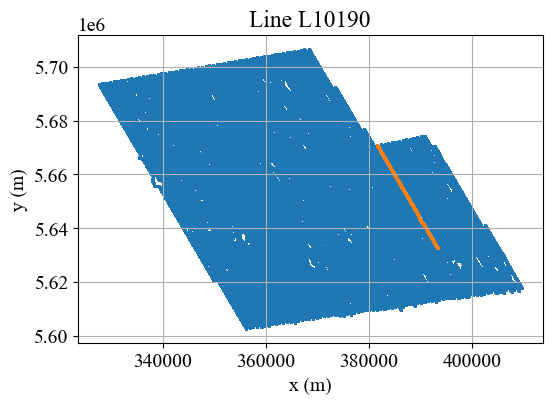

In [352]:
plt.scatter(xy[:, 0], xy[:, 1], s=1)
plt.scatter(xy[index, 0], xy[index, 1], s=1)
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title(f"Line {line_no[istart]}")

In [353]:
raws.fillna(1e-20)

,Line,bheight,TranPeak,x_wgs84,y_wgs84,flight,pwrline,zoff30[1],zoff30[2],zoff30[3],...,zoff30[15],zoff30[16],zoff30[17],zoff30[18],zoff30[19],zoff30[20],zoff30[21],zoff30[22],zoff30[23],zoff30[24]
0,L10040,51.911278,458.3756,402493.257158,5.641032e+06,503,-8,-1.425431e-09,-1.146254e-09,-9.643729e-10,...,-1.134681e-10,-9.594972e-11,-8.056059e-11,-6.506674e-11,-5.380087e-11,-4.421049e-11,-3.535748e-11,-2.819742e-11,-2.205398e-11,-1.766893e-11
1,L10040,51.951504,458.3796,402494.415637,5.641030e+06,503,-8,-1.422128e-09,-1.143961e-09,-9.625347e-10,...,-1.133346e-10,-9.575968e-11,-8.034887e-11,-6.487698e-11,-5.361121e-11,-4.407762e-11,-3.520288e-11,-2.806906e-11,-2.192132e-11,-1.753630e-11
2,L10040,51.990196,458.3752,402495.574117,5.641028e+06,503,-8,-1.418867e-09,-1.141693e-09,-9.607055e-10,...,-1.132120e-10,-9.559327e-11,-8.013431e-11,-6.470591e-11,-5.344875e-11,-4.394562e-11,-3.507516e-11,-2.795435e-11,-2.177165e-11,-1.737787e-11
3,L10040,52.028530,458.3842,402496.732597,5.641026e+06,503,-8,-1.415646e-09,-1.139441e-09,-9.588767e-10,...,-1.131146e-10,-9.543072e-11,-7.991971e-11,-6.454396e-11,-5.331321e-11,-4.384081e-11,-3.497925e-11,-2.784985e-11,-2.162800e-11,-1.722122e-11
4,L10040,52.065350,458.3826,402497.891079,5.641024e+06,503,-8,-1.412539e-09,-1.137258e-09,-9.570899e-10,...,-1.130134e-10,-9.526399e-11,-7.971802e-11,-6.438149e-11,-5.318124e-11,-4.374807e-11,-3.491266e-11,-2.776143e-11,-2.149592e-11,-1.705858e-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2468249,L10795,47.950359,460.7822,350092.607768,5.620167e+06,537,-14,-7.840540e-10,-6.313646e-10,-5.277656e-10,...,-5.095371e-11,-4.073690e-11,-3.314252e-11,-2.727702e-11,-2.102542e-11,-1.627180e-11,-1.283453e-11,-1.178583e-11,-1.098103e-11,-9.639738e-12
2468250,L10795,48.262875,460.7836,350094.300742,5.620164e+06,537,-14,-7.786760e-10,-6.269927e-10,-5.240232e-10,...,-5.057818e-11,-4.056675e-11,-3.306444e-11,-2.703948e-11,-2.084331e-11,-1.615130e-11,-1.266985e-11,-1.156742e-11,-1.080611e-11,-9.521045e-12
2468251,L10795,48.575470,460.7808,350095.995313,5.620162e+06,537,-14,-7.731655e-10,-6.224826e-10,-5.201460e-10,...,-5.014192e-11,-4.030966e-11,-3.291694e-11,-2.677578e-11,-2.065676e-11,-1.597851e-11,-1.246160e-11,-1.133130e-11,-1.056570e-11,-9.328209e-12
2468252,L10795,48.888226,460.7936,350097.689886,5.620159e+06,537,-14,-7.677030e-10,-6.180084e-10,-5.162822e-10,...,-4.974798e-11,-4.008213e-11,-3.278211e-11,-2.654657e-11,-2.050933e-11,-1.579721e-11,-1.227103e-11,-1.110839e-11,-1.026474e-11,-9.100929e-12


In [354]:
dx = 50.
values = []
values_std = []
soundings = []

for i_line, line in enumerate(line_no[istart:iend]):
    df_line = raws[raws['Line']==line]

    # Calculate distance along the "Line"
    xy = df_line[["x_wgs84", "y_wgs84"]].to_numpy()
    distance = np.sqrt(((xy-xy[0,:])**2).sum(axis=1))
    max_distance = distance.max()

    # Determine the no. of soundings per bin.
    if max_distance % dx ==0:
        n_sounding = int(max_distance / dx)
    else:
        n_sounding = int(np.round(max_distance / dx) + 1)

    # Create bins and assign each sounding to a bin
    bins = np.arange(n_sounding) * dx
    df_line.insert(0, 'distance', distance)
    # Bin distances
    df_line['bin'] = pd.cut(df_line['distance'], bins=bins)
    # Compute statistics per bin
    binned = (
        df_line.groupby('bin', observed=False)
            [['distance'] + picker[1:]]
            .mean()
    )
    binned.insert(0, 'Line', line)
    binned_std = (
        df_line.groupby('bin', observed=False)
            [['bheight'] + dheader]
            .std()
    )
    values.append(binned.values)
    values_std.append(binned_std.values)
    soundings.append(n_sounding)

df_data_binned = pd.DataFrame(data=np.vstack(values), columns=['Line', 'distance'] + picker[1:])
df_data_std_binned = pd.DataFrame(data=np.vstack(values_std), columns=['bheight'] + dheader)

In [355]:
print(f"{soundings=}")

soundings=[800]

In [356]:
from sklearn.preprocessing import MinMaxScaler
from ipywidgets import widgets, interact

In [357]:
def plot_data(line, x):
    print(line)
    x_line = x[x["Line"]==line]

    fig, axs = plt.subplots(2,1, figsize=(20, 10), constrained_layout=True)
    ax0, ax1 = axs

    # (ax0) Plot the binned locations
    ax0.plot(x["x_wgs84"], x["y_wgs84"], '.')
    ax0.plot(x_line["x_wgs84"], x_line["y_wgs84"], '.')
    ax0.plot(x_line["x_wgs84"].values[0], x_line["y_wgs84"].values[0], 'o')
    ax0.set_aspect(0.2)

    # Normalize the altitude and power line monitor data.
    scaler = MinMaxScaler(feature_range=(x_line['bheight'].min(), x_line['bheight'].max())) # Min-Max scaler for pwrline to be in the same range as bheight
    plm_norm = scaler.fit_transform(x_line['pwrline'].values.reshape([-1,1]))

    # (ax1) Plot the normalized data
    ax2 = ax1.twinx()
    ax1.semilogy(x_line['distance'], np.abs(x_line[dheader]), color='k', lw=2)
    ax2.plot(x_line['distance'], plm_norm, '-', color='red', label='PLM', lw=1.5)
    ax2.plot(x_line['distance'], x_line['bheight'], '-', label='Flight height', lw=1.5, color='magenta')
    ax1.axvline(2.61e3, c='green', lw = 3) # Infra 01
    ax1.axvline(8.4e3, c='green', lw = 3) # Altitude dramatically decreasing
    ax1.axvline(24.68e3, c='green', lw = 3) # Infra 02
    ax1.axvline(26.5e3, c='green', lw = 3) # Power line (Intersection with road)
    ax1.axvline(29.4e3, c='green', lw = 3) # Power line (Intersection with road)
    ax2.legend()

In [358]:
interact(plot_data, line=widgets.Select(options=line_no[istart:iend]), x=widgets.fixed(df_data_binned))

interactive(children=(Select(description='line', options=('L10190',), value='L10190'), Output()), _dom_classes…

<function __main__.plot_data(line, x)>

- standard deviation
$$
\sigma=\frac{1}{N}\sqrt{\sum_{i=1^N}{(x_i-\bar{x})^2}}
$$
- field normalized standard deviation (root-mean-squared relative error)
$$
\frac{\sigma}{d}=\frac{1}{N}\sqrt{\sum_{i=1^N}{\frac{(x_i-\bar{x})^2}{x_i^2}}}
$$

In [359]:
# Extract timeseries data
data_ = df_data_binned[dheader].values.astype(float)
# Extract field normalized standard deviation (root mean squared relative error)
data_rerr = (df_data_std_binned[dheader].values / np.abs(df_data_binned[dheader].values)).astype(float)

In [360]:
uniqe_lines = np.unique(df_data_binned["Line"].values)

In [361]:
# Cut-off for bad data (relative error > 3%)
criteria:float = 0.03
channel_id = np.tile(np.arange(data_.shape[1]), (data_.shape[0], 1))
cut_off = (data_rerr>criteria) * (channel_id>=0)

In [362]:
data_[cut_off] = np.nan
data_rerr[cut_off] = np.nan

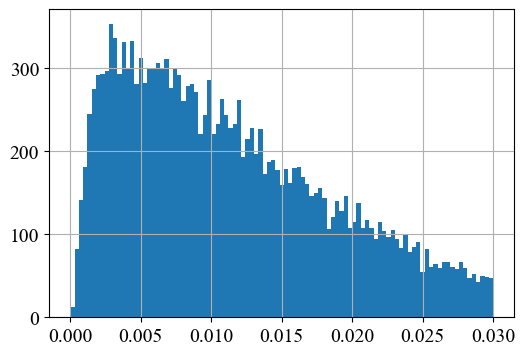

In [363]:
# Plot histogram of relative errors below the cut-off
hi = plt.hist(data_rerr[~cut_off], bins = np.linspace(0,criteria, 100))

In [364]:
def plot_soundinig(i_sounding):
    plt.errorbar(times, np.abs(data_[i_sounding,:])*1e9, yerr=data_rerr[i_sounding,:], fmt='-o')
    plt.yscale('log')
    plt.xscale('log')
    plt.xlabel("Time (s)")
    plt.ylabel("Field (nT/s)")

interact(plot_soundinig, i_sounding=widgets.IntSlider(min=0, max=data_.shape[0]-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='i_sounding', max=798), Output()), _dom_classes=('widget-…

<function __main__.plot_soundinig(i_sounding)>

In [365]:
filtered_data = pd.DataFrame(
    data = np.hstack(
        (df_data_binned.iloc[:,:8].values, data_)
    ),
    columns=df_data_binned.columns.tolist()
)

In [366]:
Q = interact(plot_data, line=widgets.Select(options=line_no[istart:iend]), x=widgets.fixed(filtered_data))

interactive(children=(Select(description='line', options=('L10190',), value='L10190'), Output()), _dom_classes…

In [367]:
criteria_uncertainty:float = 0.05

floors = 5*1e-9/ (df_data_binned["TranPeak"] * n_turns)

dobs = df_data_binned[dheader].values.flatten() # Binned Data
std = df_data_std_binned[dheader].values.flatten() # Standard deviation of Binned Data
dobs_std = abs(dobs) * criteria_uncertainty # 0.05 * Binned Data
dobs_std[std > dobs_std] = std[std > dobs_std] # Standard deviation having smaller than 0.05 * dobs will be replaced with 0.05 * dobs.
dobs_std[cut_off.flatten()] = np.inf

dobs_std += np.repeat(floors.values, iend_channel - istart_channel) # Add floors

In [368]:

from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization
topography = df_data_binned[['x_wgs84','y_wgs84', 'bheight']].values
source_heights = df_data_binned['bheight'].values
thickness = get_vertical_discretization(21, 2, 1.17)

>> Depth from the surface to the base of the bottom layer is 306.3m


In [369]:
from simpeg import maps
import simpeg.electromagnetics.time_domain as tdem
# from pymatsolver import PardisoSolver
from pymatsolver import Solver
import simpeg
from types import SimpleNamespace

In [370]:
# Define the source waveform. (unit step-off, rectangular, triangular, quarter-sine, custom)
# Triangular waveform. 
start_time = -1.74e-3
peak_time = -0.84e-3
off_time = 0.0
waveform = tdem.sources.TriangularWaveform(
    start_time,
    off_time,
    peak_time
)


In [371]:
current_times = np.linspace(start_time, off_time)
currents = [waveform.eval(t) for t in current_times]

In [372]:
radius:float = 5

In [373]:
input_data_dict = {
    "topography": topography.astype(float),
    "source_heights": source_heights.astype(float),
    "thickness": thickness,
    "time_input_currents":current_times,
    "input_currents":currents,
    "times":times,    
    "data":dobs,
    "data_std":dobs_std,    
}
inp = SimpleNamespace(**input_data_dict)

In [374]:
source_locations = np.c_[inp.topography[:,0], inp.topography[:,1], inp.topography[:,2]+inp.source_heights]
receiver_locations = np.c_[inp.topography[:,0], inp.topography[:,1],  inp.topography[:,2]+inp.source_heights]
n_sounding = source_locations.shape[0]

source_list = []
receiver_orientation = 'z'
source_orientation = 'z'

for i_sounding in range(n_sounding):    
    # waveform = tdem.sources.PiecewiseLinearWaveform(inp.time_input_currents, inp.input_currents)
    source_location = source_locations[i_sounding, :]
    receiver_location = receiver_locations[i_sounding, :]

    # Receiver list

    dbzdt_receiver = tdem.receivers.PointMagneticFluxTimeDerivative(
            receiver_location, inp.times, "z",
    )

    # Make a list containing all receivers even if just one

    # Must define the transmitter properties and associated receivers

    source_list.append(tdem.sources.CircularLoop(
        [dbzdt_receiver],
        location=source_location,
        waveform=waveform,
        radius=radius,
        i_sounding=i_sounding,
    )
    )

survey = tdem.Survey(source_list)
hz = np.r_[inp.thickness, inp.thickness[-1]]

n_layer = len(hz)
nP = n_sounding * n_layer
sigma_map = maps.ExpMap(nP=nP)

simulation = tdem.Simulation1DLayeredStitched(
    survey=survey, 
    thicknesses=inp.thickness, 
    sigmaMap=sigma_map,
    topo=inp.topography, 
    parallel=True, 
    n_cpu=8, 
    verbose=False, 
    solver=Solver,
)

n_time = inp.times.size

# Create data ojbect
data_object = simpeg.data.Data(survey, dobs=dobs, standard_deviation=inp.data_std)
dmis = simpeg.data_misfit.L2DataMisfit(simulation=simulation, data=data_object)

# nData
inds_active_dobs = dobs.shape[0] - cut_off.sum()
print (f"Percentage of the active data = {inds_active_dobs}/{len(dobs)}={inds_active_dobs.sum()/len(dobs)*100:.0f}%")

from simpeg.electromagnetics.utils.em1d_utils import set_mesh_1d
import scipy
from discretize import SimplexMesh
from simpeg.regularization.laterally_constrained import LaterallyConstrained

tri = scipy.spatial.Delaunay(inp.topography[:,:2])
mesh_radial = SimplexMesh(tri.points, tri.simplices)
mesh_vertical = set_mesh_1d(hz)
mesh_reg = [mesh_radial, mesh_vertical]

def get_active_edge_indices_with_distance(mesh_radial, mesh_vertical, maximum_distance=1000):
    nz = mesh_vertical.n_cells
    edge_lengths = mesh_radial.edge_lengths
    inds = edge_lengths < maximum_distance
    indActiveEdges = np.tile(inds.reshape([-1,1]), nz).flatten()
    return inds, indActiveEdges

inds, indActiveEdges = get_active_edge_indices_with_distance(
    mesh_radial, mesh_vertical, maximum_distance=500.
)

reg = LaterallyConstrained(
    mesh_reg, 
    mapping=simpeg.maps.IdentityMap(nP=nP),
    alpha_s = 0.,
    alpha_r = 1.,
    alpha_z = 1./2.,
    active_edges=indActiveEdges
)

opt = simpeg.optimization.ProjectedGNCG(maxIter=15, maxIterCG=50)
invProb = simpeg.inverse_problem.BaseInvProblem(dmis, reg, opt)
beta = simpeg.directives.BetaSchedule(coolingFactor=2, coolingRate=1)
betaest = simpeg.directives.BetaEstimate_ByEig(beta0_ratio=1.)
target = simpeg.directives.TargetMisfit(chifact=1)
precond = simpeg.directives.UpdatePreconditioner()
save_model_dict = simpeg.directives.SaveOutputDictEveryIteration()
save_model_dict.outDict = {}

inv = simpeg.inversion.BaseInversion(
    invProb, 
    directiveList=[
        betaest, 
        beta, 
        precond,
        target, 
        save_model_dict
    ]
)
invProb.counter = opt.counter = simpeg.utils.Counter()
opt.LSshorten = 0.5
opt.remember('xc')
m0 = np.ones(nP) * np.log(1./10.)
mest = inv.run(m0)

Percentage of the active data = 17467/19176=91%


Running inversion with SimPEG v0.22.2.dev14+g7c7f1dc80
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.

                        simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                        ***Done using same Solver, and solver_opts as the Simulation1DLayeredStitched problem***
                        
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  1.23e+01  4.09e+06  0.00e+00  4.09e+06    2.12e+05      0              
   1  6.15e+00  3.27e+05  4.14e+02  3.30e+05    3.38e+04      0              
   2  3.08e+00  2.01e+04  1.19e+03  2.38e+04    4.98e+03      0   Skip BFGS  
--------

In [375]:
name:str = "./inv_results_atem.pik"

dill.dump(save_model_dict.outDict, open(f"{name}", "wb"))

outDict = dill.load(open(f"{name}","rb"))
print(list(outDict.keys()))

[1, 2, 3]

In [376]:
iteration = len(outDict.keys())
# iteration = 3
m = outDict[iteration]['m']
dpred = outDict[iteration]['dpred']
DPRED = dpred.reshape((n_sounding, n_time))
DOBS = dobs.reshape((n_sounding, n_time))
STD = data_object.standard_deviation.reshape((n_sounding, n_time))


In [377]:
other_values = df_data_binned[['Line', 'distance','x_wgs84','y_wgs84','bheight','pwrline']].values
df_data_binned_pred = pd.DataFrame(data=np.hstack((other_values, -DPRED)), columns=['Line', 'distance','x_wgs84','y_wgs84','bheight','pwrline'] + dheader)

In [ ]:
# i_sounding = 0
def foo(i_sounding):
    plt.plot(times, -DOBS[i_sounding,:], '.')
    plt.plot(times, -DPRED[i_sounding,:])
    plt.yscale('log')
    plt.xscale('log')
    plt.title(f"x: {binned['x_wgs84'].values[i_sounding]:.1f}")
    plt.ylim(1e-12,1e-8)
interact(foo, i_sounding = widgets.IntSlider(min=0, max=n_sounding-1, continous_update=False))    


In [ ]:
from simpeg.electromagnetics.utils.em1d_utils import Stitched1DModel

In [ ]:
line = np.array([int(val.strip('L').strip('T')) for val in df_data_binned['Line'].values])

In [ ]:
model = Stitched1DModel(
    topography=inp.topography,
    physical_property=1./np.exp(m),
    line=line,
    time_stamp=np.arange(n_sounding),
    thicknesses=thickness,    
)

In [ ]:
np.argwhere( uniqe_lines == Q.widget.kwargs['line'])[0][0]

0

Text(0.5, 1.0, 'L10190')

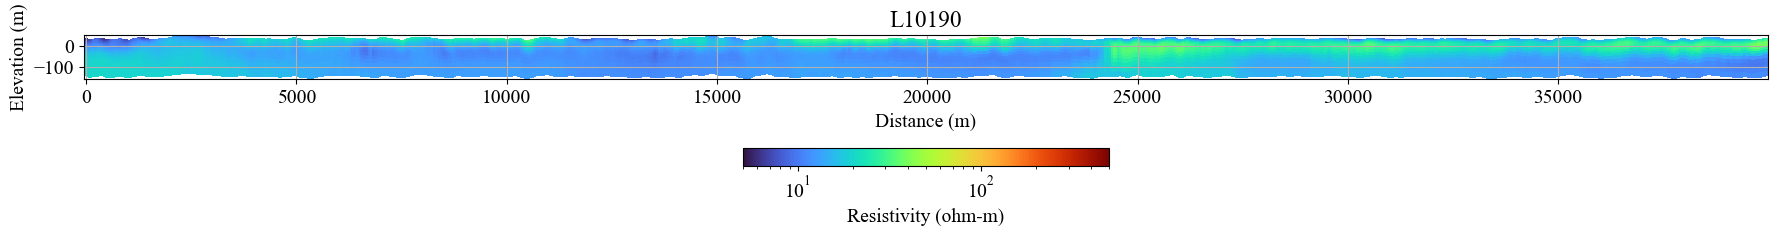

In [ ]:
fig, ax2 = plt.subplots(1,1, figsize=(18, 5))
out, ax2 = model.plot_section(
    x_axis='distance', aspect=5, dx=dx, alpha=1,
    cmap='turbo', clim=(5, 500), ax=ax2,
    show_colorbar=False,
    i_line=np.argwhere(
        uniqe_lines == Q.widget.kwargs['line'])[0][0]
        )

cb = plt.colorbar(out, ax=ax2, orientation='horizontal', fraction=0.04)
cb.set_label("Resistivity (ohm-m)")
ax2.set_title(Q.widget.kwargs['line'])

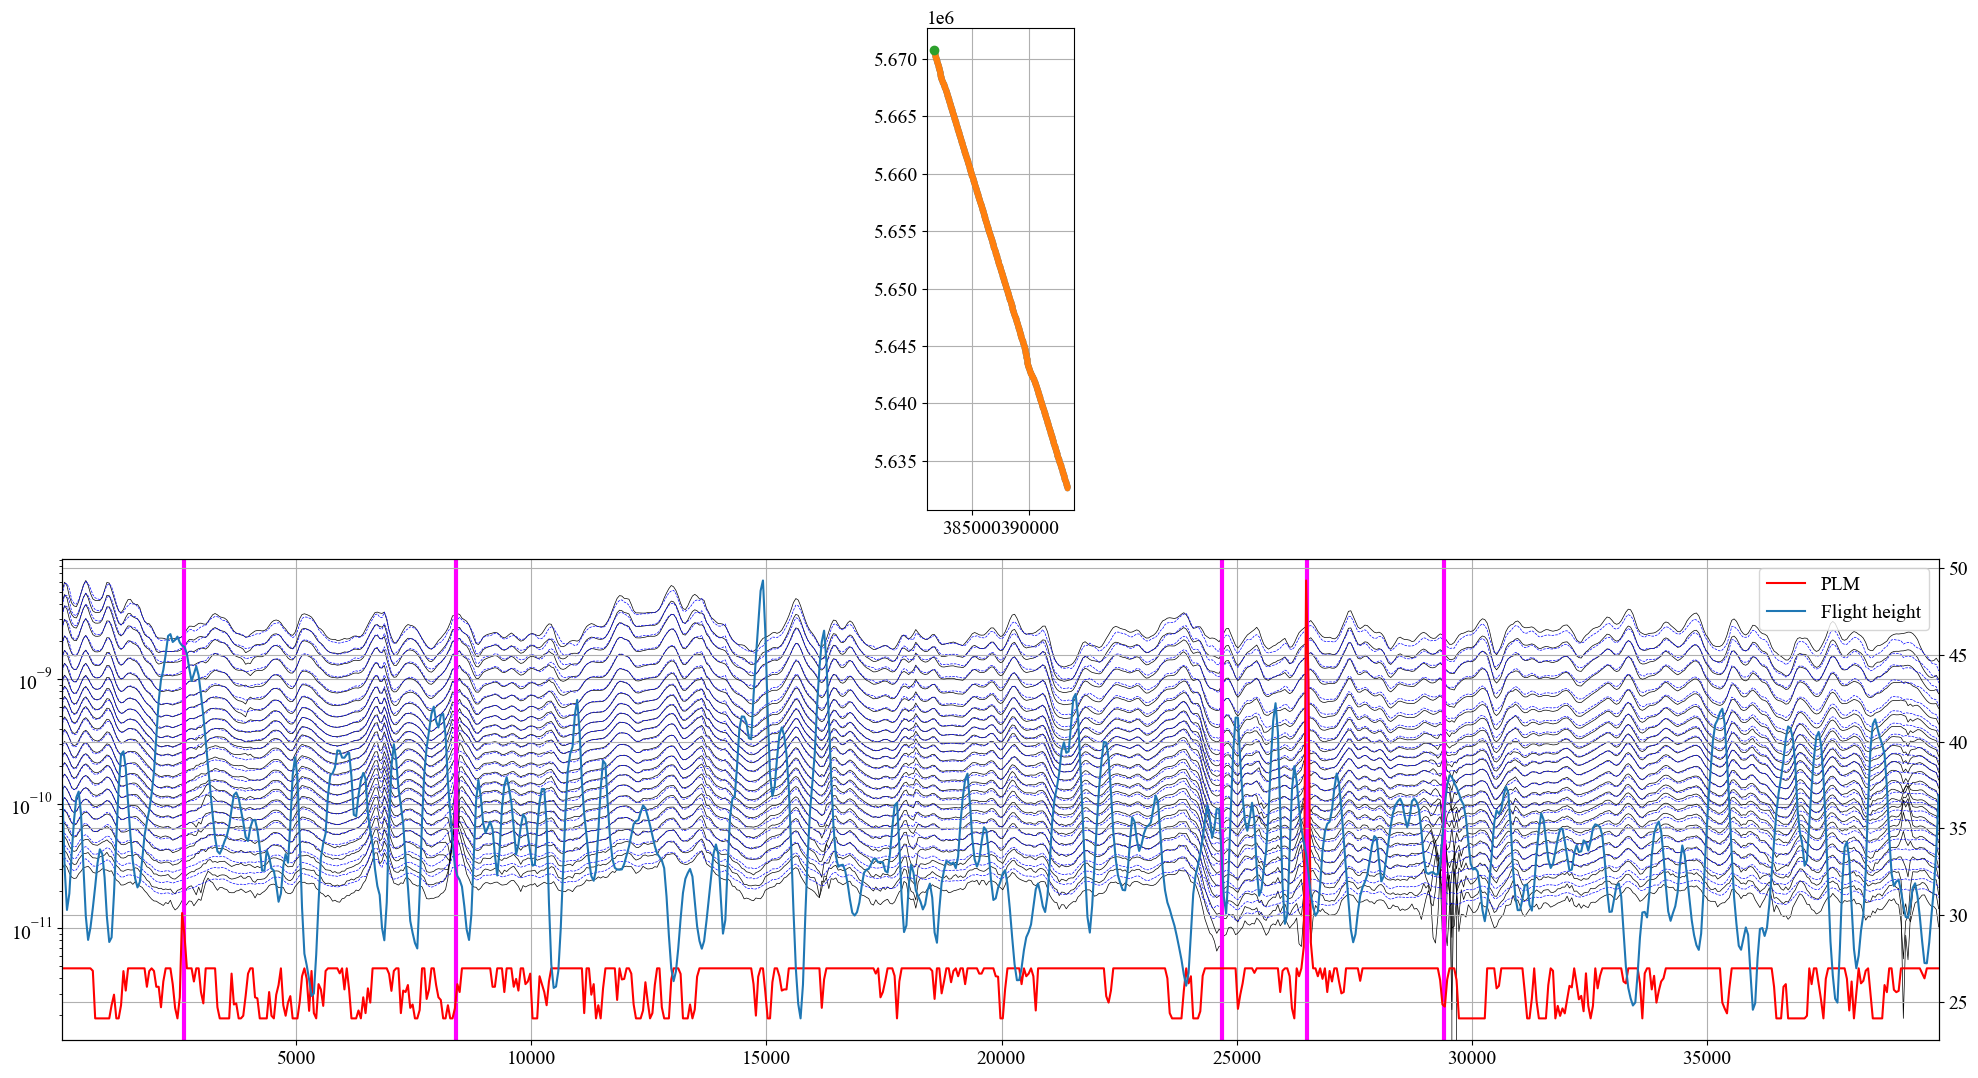

In [ ]:
for line in uniqe_lines:
    fig, axs = plt.subplots(2,1, figsize=(20, 11))
    ax0, ax = axs

    df_data_binned_line = df_data_binned[df_data_binned['Line']==line]
    df_data_binned_pred_line = df_data_binned_pred[df_data_binned_pred['Line']==line]

    ax0.plot(df_data_binned['x_wgs84'], df_data_binned['y_wgs84'], '.')    
    ax0.plot(df_data_binned_line['x_wgs84'], df_data_binned_line['y_wgs84'], '.')
    ax0.plot(df_data_binned_line['x_wgs84'].values[0], df_data_binned_line['y_wgs84'].values[0], 'o')
    ax0.set_aspect(1)
    scaler = MinMaxScaler(feature_range=(df_data_binned_line['bheight'].min(), df_data_binned_line['bheight'].max()))
    plm_norm = scaler.fit_transform(df_data_binned_line['pwrline'].values.reshape([-1,1]))

    ax_1 = ax.twinx()
    ax.semilogy(df_data_binned_line['distance'], -df_data_binned_line[dheader], 'k-', lw=0.5)
    ax.semilogy(df_data_binned_pred_line['distance'], df_data_binned_pred_line[dheader], 'b--', lw=0.5)
    ax_1.plot(df_data_binned_line['distance'], plm_norm, '-', color='red', label='PLM')
    ax_1.plot(df_data_binned_line['distance'], df_data_binned_line['bheight'], '-', label='Flight height')
    ax_1.legend()
    ax.axvline(2.61e3, c='magenta', lw = 3) # Infra 01
    ax.axvline(8.4e3, c='magenta', lw = 3) # Altitude dramatically decreasing
    ax.axvline(24.68e3, c='magenta', lw = 3) # Infra 02
    ax.axvline(26.5e3, c='magenta', lw = 3) # Power line (Intersection with road)
    ax.axvline(29.4e3, c='magenta', lw = 3) # Power line (Intersection with road)
    ax.set_xlim(df_data_binned_line['distance'].min(), df_data_binned_line['distance'].max())
    plt.tight_layout()

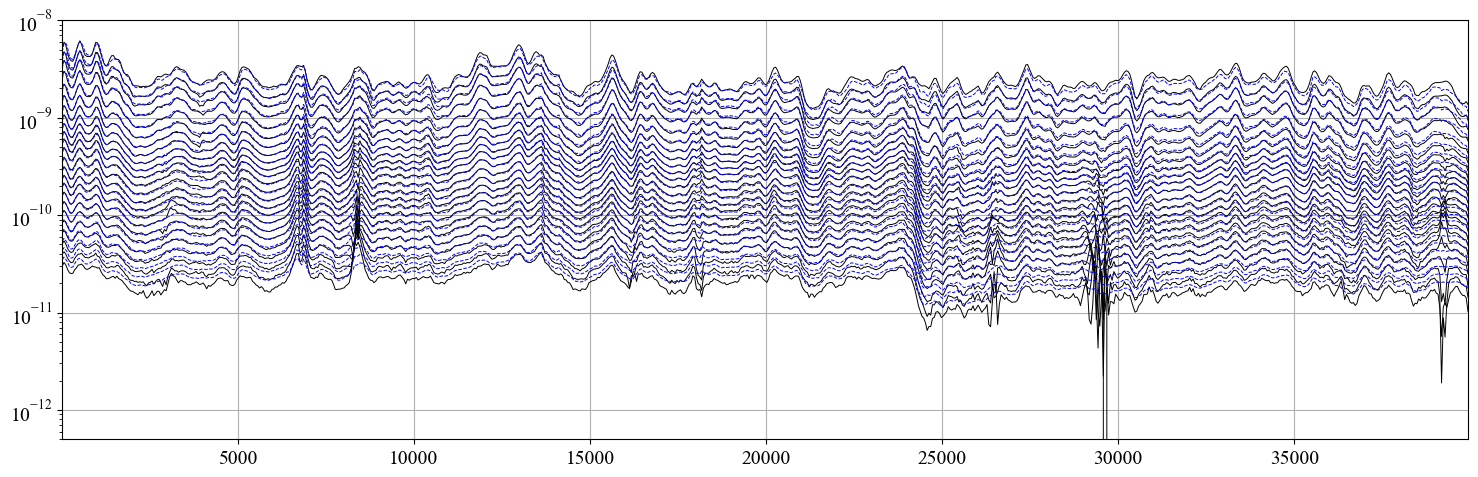

In [ ]:
fig, ax = plt.subplots(1,1, figsize = (15,5))
ax.semilogy(df_data_binned_line['distance'], -df_data_binned_line[dheader], 'k-', lw=0.7)
ax.semilogy(df_data_binned_pred_line['distance'], df_data_binned_pred_line[dheader], 'b--', lw=0.7)
ax.set_ylim([5e-13,1e-8])
# ax.axvline(2.61e3, c='magenta', lw = 3) # Infra 01
# ax.axvline(8.4e3, c='magenta', lw = 3) # Altitude dramatically decreasing
# ax.axvline(24.68e3, c='magenta', lw = 3) # Infra 02
# ax.axvline(26.5e3, c='magenta', lw = 3) # Power line (Intersection with road)
# ax.axvline(29.4e3, c='magenta', lw = 3) # Power line (Intersection with road)
ax.set_xlim(df_data_binned_line['distance'].min(), df_data_binned_line['distance'].max())
plt.tight_layout()

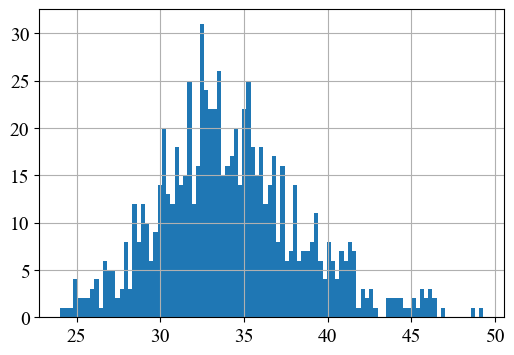

In [ ]:
out = plt.hist(df_data_binned['bheight'].values, bins=100)

In [ ]:
import geopandas as gpd
from shapely.geometry import LineString
# --- INPUTS ---
out_shp  = f"f{line_no[istart]}_lines.geojson"
# crs_epsg = 32613                 # <-- change (e.g., 4326 for lon/lat)
crs_epsg = 32612                 # <-- change (e.g., 4326 for lon/lat)

# --- READ ---
df = df_data_binned.copy()

# Required columns
xcol, ycol = "x_wgs84", "y_wgs84"

# Optional columns:
# - line_id: to create multiple line features
# - seq: to order points along each line
line_id_col = "Line" if "Line" in df.columns else None
seq_col     = "seq" if "seq" in df.columns else None

# --- BUILD LINES ---
lines = []
attrs = []

if line_id_col:
    grouped = df.groupby(line_id_col)
    for lid, g in grouped:
        coords = list(zip(g[xcol].to_numpy(), g[ycol].to_numpy()))
        if len(coords) < 2:
            continue
        lines.append(LineString(coords))
        attrs.append({line_id_col: lid})

# --- WRITE SHAPEFILE ---
gdf = gpd.GeoDataFrame(attrs, geometry=lines, crs=crs_epsg)
gdf_4326 = gdf.to_crs(4326)
gdf_4326.to_file(out_shp)  # writes .shp/.shx/.dbf/.prj

print(f"Wrote {len(gdf)} line(s) to {out_shp}")

Wrote 1 line(s) to fL10190_lines.geojson